In [57]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
#from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

Aca importamos un dataset que armamos anteriormente en otro otebook. Vamos a hacer una prediccion de la estacion de destino de la bicicleta para la estación de origen constitución.

Acá hicimos anteriormente transformaciones sobre la fecha, obteniendo diferentes columnas de dia, mes año. Además, obtuvimos un dataset de temperatura, precipitaciones y viento, para generar un posible indice que nos mejore la predicción.

In [ ]:
"year_key", "month_of_year", "day_of_month" , "iso_day_of_week", "estacion_origen", "estacion_destino", "grupo_edad", "tavg", "prcp", "wspd"

In [65]:
df = pd.read_parquet("dataset_general.parquet")
df = df[ df["estacion_origen"] == '236 - UBA SOCIALES']
df = df.drop(columns=["grupo_edad", "estacion_origen", "year_key"])
df['fecha_origen_recorrido'] = pd.to_datetime(df['fecha_origen_recorrido']).astype('datetime64[s]')
df['fecha_destino_recorrido'] = pd.to_datetime(df['fecha_destino_recorrido']).astype('datetime64[s]')
df['date_key'] = pd.to_datetime(df['date_key']).astype('datetime64[s]')
df['date'] = pd.to_datetime(df['date']).astype('datetime64[s]')

In [62]:
df.columns

Index(['fecha_origen_recorrido', 'fecha_destino_recorrido',
       'duracion_estim_seg', 'modelo_bicicleta', 'estacion_destino',
       'genero_usuario', 'edad_usuario', 'date_key', 'day_of_year', 'week_key',
       'week_of_year', 'day_of_week', 'iso_day_of_week', 'day_name',
       'first_day_of_week', 'last_day_of_week', 'month_key', 'month_of_year',
       'day_of_month', 'month_name_short', 'month_name', 'first_day_of_month',
       'last_day_of_month', 'quarter_key', 'quarter_of_year', 'day_of_quarter',
       'quarter_desc_short', 'quarter_desc', 'first_day_of_quarter',
       'last_day_of_quarter', 'first_day_of_year', 'last_day_of_year',
       'ordinal_weekday_of_month', 'date', 'tavg', 'prcp', 'wspd'],
      dtype='object')

para hacer el analisis vamos a hacerlo sobre la estación de la uba de sociales

In [60]:
df

,fecha_origen_recorrido,fecha_destino_recorrido,duracion_estim_seg,modelo_bicicleta,estacion_destino,genero_usuario,edad_usuario,date_key,day_of_year,week_key,...,quarter_desc,first_day_of_quarter,last_day_of_quarter,first_day_of_year,last_day_of_year,ordinal_weekday_of_month,date,tavg,prcp,wspd
622,2024-10-18 17:33:09,2024-10-18 17:54:35,832,FIT,131- HOSPITAL DE CLÍNICAS,MALE,31,2024-10-18,292,202442,...,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,2024-10-18,21.1,0.0,8.9
1721,2024-10-18 13:58:03,2024-10-18 14:16:32,926,FIT,064 - RIOBAMBA,None,<NA>,2024-10-18,292,202442,...,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,2024-10-18,21.1,0.0,8.9
1736,2024-10-18 17:36:24,2024-10-18 18:08:33,1736,FIT,286 - FILOSOFIA Y LETRAS,None,<NA>,2024-10-18,292,202442,...,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,2024-10-18,21.1,0.0,8.9
1948,2024-10-18 12:38:49,2024-10-18 12:54:38,816,ICONIC,041 - PARQUE PATRICIOS II,None,<NA>,2024-10-18,292,202442,...,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,2024-10-18,21.1,0.0,8.9
2536,2024-10-17 18:37:14,2024-10-17 19:00:11,592,ICONIC,084 - TEATRO PICADERO,MALE,29,2024-10-17,291,202442,...,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,2024-10-17,26.6,0.5,7.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495632,2024-10-25 15:29:46,2024-10-25 15:45:42,490,ICONIC,073 - Ruy Díaz de Guzmán,None,<NA>,2024-10-25,299,202443,...,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,2024-10-25,22.6,3.3,6.7
3500105,2024-10-28 08:35:15,2024-10-28 08:48:34,683,ICONIC,152 - JULIETA LANTERI,MALE,33,2024-10-28,302,202444,...,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,2024-10-28,24.4,0.0,8.2
3500462,2024-10-26 13:41:28,2024-10-26 13:59:11,821,FIT,179 - CASA SAN,MALE,19,2024-10-26,300,202443,...,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,2024-10-26,16.9,0.0,4.7
3500495,2024-10-26 19:24:19,2024-10-26 19:57:17,385,FIT,008 - Congreso,MALE,62,2024-10-26,300,202443,...,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,2024-10-26,16.9,0.0,4.7


Para analizar desbalanceo de la variable de salida, vamos a ver la cantidad de salida de las 30 estaciones de destino mas grandes

In [24]:
# Get the top 20 categories by count
top_30 = df['estacion_destino'].value_counts().nlargest(30).index

# Filter the DataFrame to only include these top 20 categories
df_top30 = df[df['estacion_destino'].isin(top_30)]

<Axes: xlabel='percent', ylabel='estacion_destino'>

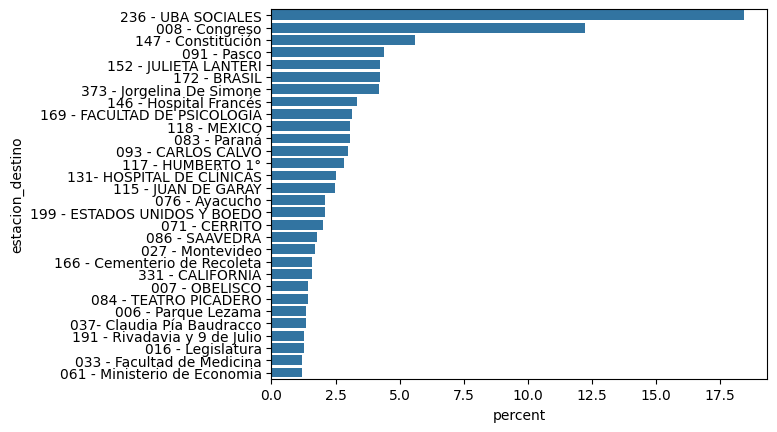

In [26]:
sns.countplot(df_top30, y="estacion_destino", order=top_30, stat='percent')

Podemos ver como en general las clases presentan una distribucion medianamente uniforme descendente, salvo por dos casos atipicos: la misma estación de uba sociales, y la estación de congreso. Vamos a ver metodologías para corregir estos desbalanceos. Consideramos que para este caso, puede existir un desbalance natural de la información, que no necesariamente es malo, ya que muestra la mayor frecuencia de utilización del transporte. Como criterio, vamos a retirar la clase mayoritaria, debido a que a fines analiticos, no podemos obtener mucha información de un viaje que salió y llegó a la misma estación.

In [66]:
df = df[df['estacion_destino']!= '236 - UBA SOCIALES']

<Axes: xlabel='percent', ylabel='estacion_destino'>

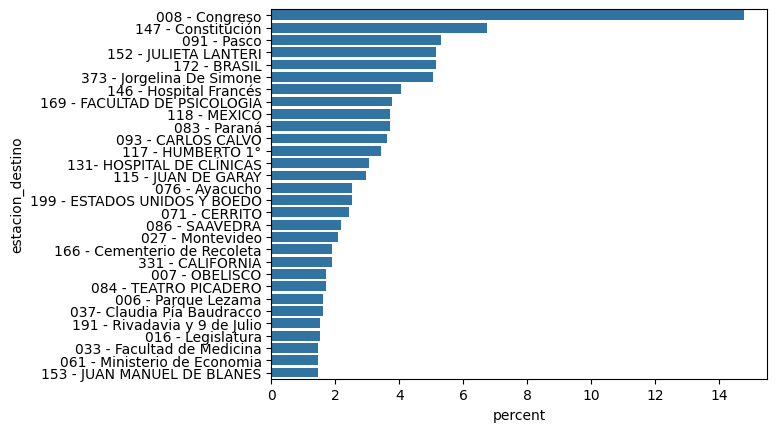

In [28]:
# Get the top 20 categories by count
top_30 = df['estacion_destino'].value_counts().nlargest(30).index

# Filter the DataFrame to only include these top 20 categories
df_top30 = df[df['estacion_destino'].isin(top_30)]
sns.countplot(df_top30, y="estacion_destino", order=top_30, stat='percent')


In [34]:
df

,year_key,month_of_year,day_of_month,iso_day_of_week,estacion_origen,estacion_destino,tavg,prcp,wspd
622,2024,10,18,5,236 - UBA SOCIALES,131- HOSPITAL DE CLÍNICAS,21.1,0.0,8.9
1721,2024,10,18,5,236 - UBA SOCIALES,064 - RIOBAMBA,21.1,0.0,8.9
1736,2024,10,18,5,236 - UBA SOCIALES,286 - FILOSOFIA Y LETRAS,21.1,0.0,8.9
1948,2024,10,18,5,236 - UBA SOCIALES,041 - PARQUE PATRICIOS II,21.1,0.0,8.9
2536,2024,10,17,4,236 - UBA SOCIALES,084 - TEATRO PICADERO,26.6,0.5,7.1
...,...,...,...,...,...,...,...,...,...
3495632,2024,10,25,5,236 - UBA SOCIALES,073 - Ruy Díaz de Guzmán,22.6,3.3,6.7
3500105,2024,10,28,1,236 - UBA SOCIALES,152 - JULIETA LANTERI,24.4,0.0,8.2
3500462,2024,10,26,6,236 - UBA SOCIALES,179 - CASA SAN,16.9,0.0,4.7
3500495,2024,10,26,6,236 - UBA SOCIALES,008 - Congreso,16.9,0.0,4.7


Otra metodología que puede llegarse a utilizar en este caso es la de underfitting de la categoría mayoritaria: retirar muestras de la estación de congreso:

In [53]:
X = df.drop(columns="estacion_destino").copy()
y = df["estacion_destino"].copy()

In [38]:
# Undersampling
undersample = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = undersample.fit_resample(X_train, y_train)

In [39]:
X_train_us

,year_key,month_of_year,day_of_month,iso_day_of_week,estacion_origen,tavg,prcp,wspd
109652,2024,12,17,2,236 - UBA SOCIALES,23.3,9.9,9.3
2430537,2024,10,11,5,236 - UBA SOCIALES,22.3,0.0,6.6
2102863,2024,11,1,5,236 - UBA SOCIALES,25.9,0.0,11.7
332267,2024,12,6,5,236 - UBA SOCIALES,23.7,14.0,9.6
1764362,2024,11,15,5,236 - UBA SOCIALES,26.5,0.0,10.5
...,...,...,...,...,...,...,...,...
2458053,2024,10,8,2,236 - UBA SOCIALES,20.8,0.0,9.7
3380547,2024,10,16,3,236 - UBA SOCIALES,20.6,0.0,6.8
1963559,2024,11,30,6,236 - UBA SOCIALES,21.7,0.0,8.9
1247498,2024,11,6,3,236 - UBA SOCIALES,21.7,0.0,11.3


In [46]:
X

,year_key,month_of_year,day_of_month,iso_day_of_week,tavg,prcp,wspd
622,2024,10,18,5,21.1,0.0,8.9
1721,2024,10,18,5,21.1,0.0,8.9
1736,2024,10,18,5,21.1,0.0,8.9
1948,2024,10,18,5,21.1,0.0,8.9
2536,2024,10,17,4,26.6,0.5,7.1
...,...,...,...,...,...,...,...
3495632,2024,10,25,5,22.6,3.3,6.7
3500105,2024,10,28,1,24.4,0.0,8.2
3500462,2024,10,26,6,16.9,0.0,4.7
3500495,2024,10,26,6,16.9,0.0,4.7


Ahora vamos a empezar a realizar analisis entre varaibles:

In [67]:
from dython.nominal import associations
import matplotlib.pyplot as plt
# Calcular asociaciones para todas las variables
associations(df, figsize=(12, 12), cmap='coolwarm')


ValueError: 'datetime64[s]' is too specific of a frequency, try passing 'datetime64'

<Axes: >

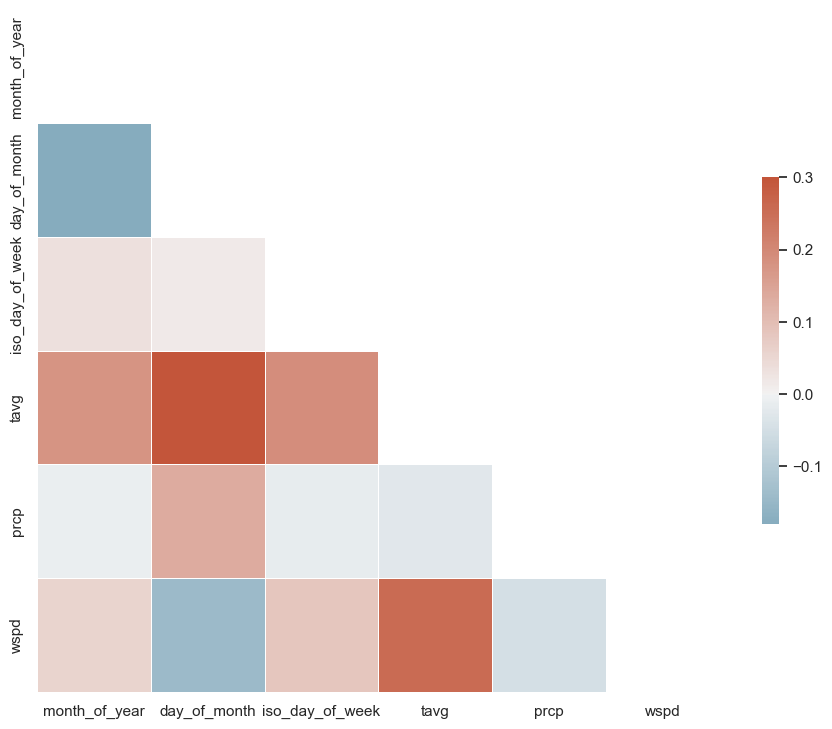

In [55]:
from string import ascii_letters
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

# Generate a large random dataset
rs = np.random.RandomState(33)

# Compute the correlation matrix
corr = X.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})